--- house price forecast  ----

In [1]:
import kagglehub
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns



path = kagglehub.dataset_download("swarupsudulaganti/uk-house-price-prediction-dataset-2015-to-2024")
file_name = "UK_House_Price_Prediction_dataset_2015_to_2024.csv"
csv_path = os.path.join(path, file_name)

df = pd.read_csv(csv_path)
df.head()


/Users/gilnanderson/Documents/Gil/Documentos/2026/Aulas_Python/Aula 3 - Projeto de Previsão com Machine Learning/Exercicio/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,price,date,postcode,property_type,new_build,freehold,street,locality,town,district,county
0,735000,2017-08-07,LE17 5AP,D,N,F,CLAYBROOKE COURT,CLAYBROOKE PARVA,LUTTERWORTH,HARBOROUGH,LEICESTERSHIRE
1,160000,2023-02-03,SA11 4BD,T,N,F,GORED COTTAGES,MELINCOURT,NEATH,NEATH PORT TALBOT,NEATH PORT TALBOT
2,176500,2015-01-06,ME3 0DQ,S,N,F,GREEN LANE,ISLE OF GRAIN,ROCHESTER,MEDWAY,MEDWAY
3,625000,2021-10-13,RH20 3EU,D,N,F,LINFIELD COPSE,THAKEHAM,PULBOROUGH,HORSHAM,WEST SUSSEX
4,202000,2019-09-27,SN13 8EN,S,N,F,CLYDESDALE ROAD,BOX,CORSHAM,WILTSHIRE,WILTSHIRE


In [2]:
# Isto vai mostrar-nos o tipo de dados de cada coluna (texto, número inteiro, etc.)
print("--- INFORMAÇÕES DO DATASET ---")
df.info()

# Isto vai mostrar-nos como são exatamente as primeiras 5 casas do teu ficheiro
print("\n--- PRIMEIRAS 5 LINHAS ---")
print(df.head())

--- INFORMAÇÕES DO DATASET ---
<class 'pandas.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   price          90000 non-null  int64
 1   date           90000 non-null  str  
 2   postcode       90000 non-null  str  
 3   property_type  90000 non-null  str  
 4   new_build      90000 non-null  str  
 5   freehold       90000 non-null  str  
 6   street         90000 non-null  str  
 7   locality       90000 non-null  str  
 8   town           90000 non-null  str  
 9   district       90000 non-null  str  
 10  county         90000 non-null  str  
dtypes: int64(1), str(10)
memory usage: 7.6 MB

--- PRIMEIRAS 5 LINHAS ---
    price        date  postcode property_type new_build freehold  \
0  735000  2017-08-07  LE17 5AP             D         N        F   
1  160000  2023-02-03  SA11 4BD             T         N        F   
2  176500  2015-01-06   ME3 0DQ             S 

In [3]:
print("Starting data preparation...")

# --- 1. ENGENHARIA DE ATRIBUTOS E FILTRAGEM DE RUÍDO ---
df['year'] = pd.to_datetime(df['date']).dt.year

# Extrair a região (Outcode) dividindo o texto no espaço em branco
df['outcode'] = df['postcode'].str.split(' ').str[0]

# Remover o postcode original e as outras colunas hiper-específicas
colunas_remover = ['date', 'postcode', 'street', 'locality', 'town', 'district']
df_limpo = df.drop(columns=colunas_remover)

# --- 2. TRATAMENTO DE OUTLIERS ---
limite_preco = df_limpo['price'].quantile(0.95)
df_comum = df_limpo[df_limpo['price'] <= limite_preco].copy()

print(f"Removed houses above £{limite_preco:,.2f} (Top 5% removed).")

# --- 3. TRANSFORMAÇÃO DE TEXTO PARA NÚMERO ---
le = LabelEncoder()
colunas_texto = df_comum.select_dtypes(include=['object', 'string', 'str']).columns

for col in colunas_texto:
    df_comum[col] = le.fit_transform(df_comum[col].astype(str))

Starting data preparation...
Removed houses above £705,025.00 (Top 5% removed).


In [4]:
# --- 4. PREPARAÇÃO PARA O TREINO ---
X = df_comum.drop('price', axis=1)
y = df_comum['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 5. TREINO DO MODELO ---
modelo = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42)
print("Training the model focused on the regular market...")
modelo.fit(X_train, y_train)

Training the model focused on the regular market...


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [5]:
# df.columns.tolist()

# --- 6. AVALIAÇÃO COM FORMATAÇÃO UK ---
previsoes = modelo.predict(X_test)
mae = mean_absolute_error(y_test, previsoes)
r2 = r2_score(y_test, previsoes)

print(f"\nMean Absolute Error (MAE): £{mae:,.2f}")
print(f"R² Score: {r2:.2f}")


Mean Absolute Error (MAE): £68,479.23
R² Score: 0.53



Generating the updated feature importance chart...


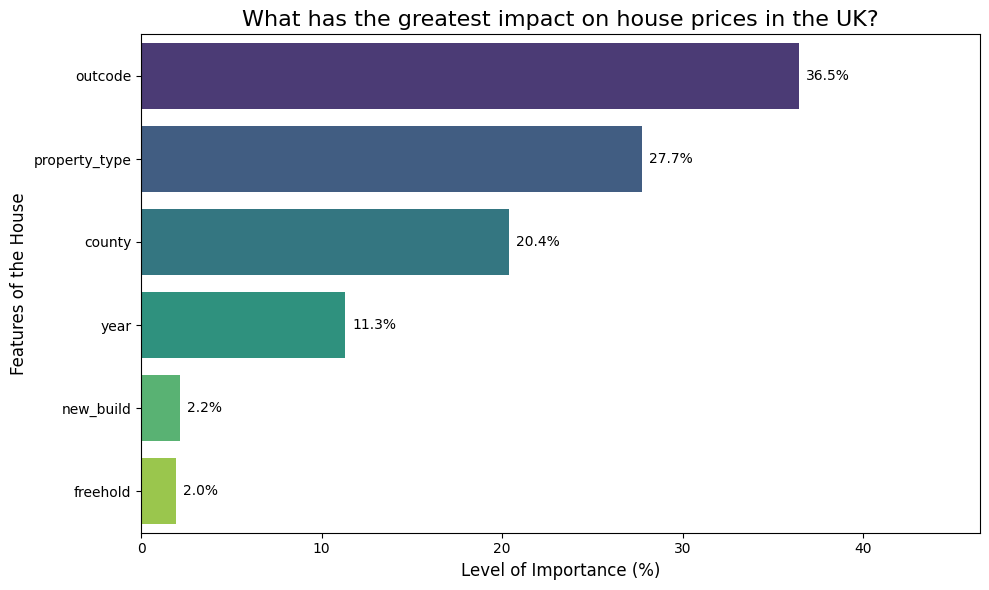

In [6]:
# --- 7. GRÁFICO DE IMPORTÂNCIA DAS VARIÁVEIS COM PORCENTAGEM ---
print("\nGenerating the updated feature importance chart...")

importancias = modelo.feature_importances_ * 100
nomes_das_colunas = X_train.columns

tabela_importancia = pd.DataFrame({
    'Feature': nomes_das_colunas,
    'Importance (%)': importancias
}).sort_values(by='Importance (%)', ascending=False)

plt.figure(figsize=(10, 6))

# Desenhamos o gráfico (adicionamos hue='Feature' e legend=False para ficar no padrão mais moderno do Seaborn)
ax = sns.barplot(x='Importance (%)', y='Feature', data=tabela_importancia, palette='viridis', hue='Feature', legend=False)

# A MÁGICA CORRIGIDA: Um laço 'for' para passar por TODAS as barras (containers)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=5)

plt.title('What has the greatest impact on house prices in the UK?', fontsize=16)
plt.xlabel('Level of Importance (%)', fontsize=12)
plt.ylabel('Features of the House', fontsize=12)

# Ajuste do limite X para caber o texto da maior barra
plt.xlim(0, tabela_importancia['Importance (%)'].max() + 10)

plt.tight_layout()
plt.show()

In [7]:
import random
from datetime import datetime, timedelta

print("Iniciando a geração de dados simulados...")

# Definir a quantidade de linhas que queremos no nosso CSV
n_registros = 1000

# --- 1. GERAR DATAS ALEATÓRIAS ---
data_inicial = datetime(2015, 1, 1)
data_final = datetime(2024, 12, 31)
dias_totais = (data_final - data_inicial).days

datas_aleatorias = []
for _ in range(n_registros):
    dias_sorteados = random.randint(0, dias_totais)
    data_sorteada = data_inicial + timedelta(days=dias_sorteados)
    # Formatando a data no estilo YYYY-MM-DD igual ao Kaggle
    datas_aleatorias.append(data_sorteada.strftime('%Y-%m-%d'))

# --- 2. LISTAS DE CATEGORIAS DO REINO UNIDO ---
tipos_propriedade = ['D', 'S', 'T', 'F', 'O']
novas_construcoes = ['Y', 'N'] # Yes (Sim), No (Não)
tipos_posse = ['F', 'L']       # Freehold (Propriedade Plena), Leasehold (Arrendamento)
condados = ['GREATER LONDON', 'WEST MIDLANDS', 'GREATER MANCHESTER', 'WEST YORKSHIRE', 'KENT']

# --- 3. CONSTRUIR A TABELA (DICIONÁRIO) ---
dados_simulados = {
    'date': datas_aleatorias,
    'postcode': [f"AB{random.randint(1,9)} {random.randint(1,9)}CD" for _ in range(n_registros)],
    'property_type': [random.choice(tipos_propriedade) for _ in range(n_registros)],
    'new_build': [random.choice(novas_construcoes) for _ in range(n_registros)],
    'freehold': [random.choice(tipos_posse) for _ in range(n_registros)],
    'street': [f"Rua Ficticia {i}" for i in range(n_registros)],
    'locality': ['Localidade Desconhecida' for _ in range(n_registros)],
    'town': ['Cidade Ficticia' for _ in range(n_registros)],
    'district': ['Distrito Ficticio' for _ in range(n_registros)],
    'county': [random.choice(condados) for _ in range(n_registros)]
}
# Nota: A coluna 'price' foi intencionalmente deixada de fora!

# --- 4. EXPORTAR PARA CSV ---
df_simulado = pd.DataFrame(dados_simulados)
nome_do_arquivo = "casas_sem_preco.csv"

# O index=False impede que o Pandas crie uma coluna extra com a numeração das linhas
df_simulado.to_csv(nome_do_arquivo, index=False)

print(f"Sucesso! O arquivo '{nome_do_arquivo}' foi criado com {n_registros} registros.")
print("Ele contém as exatas 10 colunas de características (sem o preço) prontas para o teste.")

Iniciando a geração de dados simulados...
Sucesso! O arquivo 'casas_sem_preco.csv' foi criado com 1000 registros.
Ele contém as exatas 10 colunas de características (sem o preço) prontas para o teste.


In [9]:
# === TESTE DE INFERÊNCIA COM NOVOS DADOS ===

print("\nIniciando o teste prático com casas sem preço...")

# 1. Carregar o novo arquivo (Substitua 'casas_sem_preco.csv' pelo nome real do seu arquivo)
caminho_arquivo_teste = "casas_sem_preco.csv" 
df_teste = pd.read_csv(caminho_arquivo_teste)

print(f"Carregamos {len(df_teste)} registros novos para previsão.")

# 2. Fazer a MESMA faxina (Feature Engineering)
df_teste['year'] = pd.to_datetime(df_teste['date']).dt.year
df_teste['outcode'] = df_teste['postcode'].str.split(' ').str[0]
colunas_remover = ['date', 'postcode', 'street', 'locality', 'town', 'district']
df_teste_limpo = df_teste.drop(columns=colunas_remover)


# --- 3. TRANSFORMAÇÃO DE TEXTO PARA NÚMERO ---
for col in colunas_texto: # colunas_texto vem do nosso script de treino e agora inclui o 'outcode'
    le_temporario = LabelEncoder()
    # Junta as palavras conhecidas para mapear corretamente (incluindo os novos outcodes)
    todas_categorias = df_comum[col].astype(str).tolist() + df_teste_limpo[col].astype(str).tolist()
    le_temporario.fit(todas_categorias)
    
    # Transforma apenas os dados novos
    df_teste_limpo[col] = le_temporario.transform(df_teste_limpo[col].astype(str))

# --- 4. FAZER AS PREVISÕES ---
previsoes_finais = modelo.predict(df_teste_limpo)

# --- 5. ORGANIZAR OS RESULTADOS ---
df_teste['Predicted_Price'] = previsoes_finais
# Formatando no estilo UK
df_teste['Predicted_Price'] = df_teste['Predicted_Price'].apply(lambda x: f"£{x:,.2f}")

# --- 6. SALVAR ---
nome_arquivo_saida = "resultado_previsoes_uk.csv"
df_teste.to_csv(nome_arquivo_saida, index=False)

print(f"\nSucesso! As previsões foram geradas e salvas no arquivo: {nome_arquivo_saida}")


Iniciando o teste prático com casas sem preço...
Carregamos 1000 registros novos para previsão.

Sucesso! As previsões foram geradas e salvas no arquivo: resultado_previsoes_uk.csv


In [10]:
print("Carregando o arquivo final com as previsões de preço...\n")

# 1. Lê o arquivo CSV com os resultados que salvamos anteriormente
df_resultados = pd.read_csv("resultado_previsoes_uk.csv")

# 2. Exibe as 10 primeiras linhas usando a formatação visual rica do display()
print("--- RESULTADO DAS PREVISÕES (PRIMEIRAS 10 CASAS) ---")
display(df_resultados.head(10))

Carregando o arquivo final com as previsões de preço...

--- RESULTADO DAS PREVISÕES (PRIMEIRAS 10 CASAS) ---


,date,postcode,property_type,new_build,freehold,street,locality,town,district,county,year,outcode,Predicted_Price
0,2023-12-22,AB3 8CD,S,N,L,Rua Ficticia 0,Localidade Desconhecida,Cidade Ficticia,Distrito Ficticio,WEST MIDLANDS,2023,AB3,"£296,927.23"
1,2019-02-14,AB9 5CD,T,Y,L,Rua Ficticia 1,Localidade Desconhecida,Cidade Ficticia,Distrito Ficticio,KENT,2019,AB9,"£216,768.15"
2,2017-08-22,AB8 7CD,T,Y,F,Rua Ficticia 2,Localidade Desconhecida,Cidade Ficticia,Distrito Ficticio,KENT,2017,AB8,"£194,899.54"
3,2017-07-04,AB3 6CD,O,N,L,Rua Ficticia 3,Localidade Desconhecida,Cidade Ficticia,Distrito Ficticio,WEST MIDLANDS,2017,AB3,"£194,899.54"
4,2022-05-17,AB9 7CD,T,Y,F,Rua Ficticia 4,Localidade Desconhecida,Cidade Ficticia,Distrito Ficticio,WEST YORKSHIRE,2022,AB9,"£301,076.95"
5,2019-01-29,AB1 4CD,T,N,L,Rua Ficticia 5,Localidade Desconhecida,Cidade Ficticia,Distrito Ficticio,KENT,2019,AB1,"£216,768.15"
6,2019-08-25,AB3 1CD,S,Y,F,Rua Ficticia 6,Localidade Desconhecida,Cidade Ficticia,Distrito Ficticio,KENT,2019,AB3,"£216,768.15"
7,2016-07-14,AB4 7CD,D,N,L,Rua Ficticia 7,Localidade Desconhecida,Cidade Ficticia,Distrito Ficticio,WEST MIDLANDS,2016,AB4,"£197,294.67"
8,2019-05-28,AB1 8CD,T,Y,L,Rua Ficticia 8,Localidade Desconhecida,Cidade Ficticia,Distrito Ficticio,WEST MIDLANDS,2019,AB1,"£216,768.15"
9,2024-03-19,AB8 2CD,F,Y,L,Rua Ficticia 9,Localidade Desconhecida,Cidade Ficticia,Distrito Ficticio,WEST MIDLANDS,2024,AB8,"£313,469.73"


In [12]:
# import joblib

# print("\nIniciando o salvamento do modelo...")

# 1. Definir o nome do arquivo onde o "cérebro" será salvo
# A extensão .pkl (Pickle) é o padrão para modelos no Python
# nome_arquivo_modelo = 'modelo_previsao_casas_uk.pkl'

# # 2. Salvar (Dump) o modelo no disco rígido
# joblib.dump(modelo, nome_arquivo_modelo)

# print(f"🎉 SUCESSO! O seu modelo foi salvo como '{nome_arquivo_modelo}'.")
# print("Agora você pode usar este arquivo em qualquer outro projeto de Python!")


import os
import joblib

print("Iniciando o salvamento na pasta correta...\n")

# 1. O caminho exato que você me passou
minha_pasta_exata = "/Users/gilnanderson/Documents/Gil/Documentos/2026/Aulas_Python/Projeto Previsão preço casas"

# 2. Nome do arquivo do modelo
nome_arquivo_modelo = "modelo_previsao_casas_uk.pkl"

# 3. Juntando a pasta com o arquivo de forma segura
caminho_completo = os.path.join(minha_pasta_exata, nome_arquivo_modelo)

# 4. Salvando o "cérebro" do modelo no disco rígido
joblib.dump(modelo, caminho_completo)

print(f"🎉 SUCESSO! Vá até a sua pasta e verifique. O modelo foi salvo EXATAMENTE aqui:\n{caminho_completo}")


# =====================================================================
# CÓDIGO BÔNUS: COMO CARREGAR O MODELO NO SEU PRÓXIMO PROJETO
# =====================================================================
# Quando você criar um arquivo Python novo amanhã, você fará apenas isso:
#
# import joblib
# modelo_pronto = joblib.load('modelo_previsao_casas_uk.pkl')
# previsao = modelo_pronto.predict(dados_da_casa_nova)

Iniciando o salvamento na pasta correta...

🎉 SUCESSO! Vá até a sua pasta e verifique. O modelo foi salvo EXATAMENTE aqui:
/Users/gilnanderson/Documents/Gil/Documentos/2026/Aulas_Python/Projeto Previsão preço casas/modelo_previsao_casas_uk.pkl
